## Przygotowanie

Przed rozpoczęciem pracy z notatnikiem proszę zmienić jego nazwę dodając na początku numer albumu, imię i nazwisko.
{nr_albumu}\_{imię}\_{nazwisko}\_{nazwa}

Po wykonaniu wszystkich zadań proszę przesłać wypełniony notatnik przez TEAMS.

## Perceptron liniowy

Klasyfikacja jest dziedziną bardzo popularną i istnieje wiele różnych algorytmów uczenia maszynowego, które służą do rozwiązywania problemów klasyfikacji. My przyjrzymy się działaniu podstawowego algorytmu, jednak jego dobre zrozumienie jest kluczowe do pojęcia bardziej zaawansowanych metod. 

Perceptron, bo o nim będzie mowa w tym notatniku, używany jest do klasyfikacji binarnej. Posiada duże ograniczenie, które mówi, że algorytm jest zbieżny w skończonej liczbie kroków, jeśli zbiór danych jest liniowo separowalny. Co oznacza, że zbiór jest liniowo separowalny? Że próbki należące do różnych klas można oddzielić za pomocą prostej w przypadku dwuwymiarowym, płaszczyzny w przypadku trójwymiarowym i hiperpłaszczyzny w przypadku $N$-wymiarowym.

Spójrzmy jeszcze raz na ankietę prezentującą podział na płeć ze względu na wzrost i wagę.

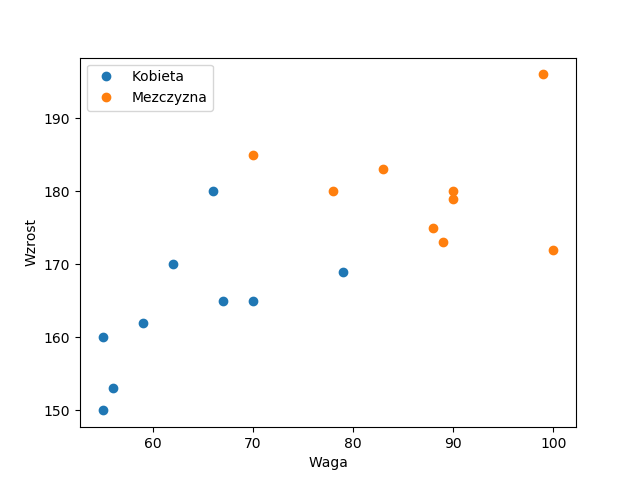

Czy ten zbiór jest liniowo separowalny? Jest, ponieważ jesteśmy w stanie narysować wiele różnych prostych, które oddzielają kobiety od mężczyzn. Zadanie perceptronu właśnie na tym polega, aby znaleźć prostą (w najprostszym przypadku), która oddziela od siebie dwie klasy i na podstawie stworzonego podziału klasyfikować nowe próbki.


### Budowa sztucznego neuronu

Perceptron został stworzony na bazie sztucznego neuronu. Twórcami modelu sztuczego neuronu byli McCulloch i Pitts, którzy w roku 1943 zainspirowani działaniem biologicznego neuronu, zaproponowali jego budowę.


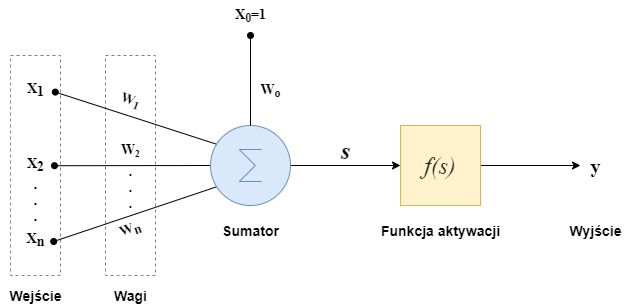

Sztuczny neuron składa się na następujących elementów:

* **Wejście** - warstwa odpowiadająca za przyjmowanie danych wejściowych. Istnieje tyle połączeń do neuronu, ile jest cech w zestawie danych. Przykładowo, jeśli chcemy rozpoznawać płeć na podstawie wagi, wzrostu, długości stopy i długości włosów, to mamy 4 cechy opisujące osobę, więc będą 4 połączenia w warstwie wejściowej.


* **Wagi** - każde połączenie do neuronu ma skojarzoną ze sobą wagę. Wagi są tym, czym były współczynniki regresji w algorytmie regresji. Tutaj przechowywana jest "wiedza" neuronu.


* **Sumator** - element, który odpowiada za zsmumowanie wszystkich iloczynów wejść i wag. Jest to tak zwane pobudzenie neuronu, czyli ważona suma wejść. Do sumatora wchodzi jeszcze jedno dodatkowe połączenie. Na jego wejściu zawsze podawana jest wartość $1$, a waga skojarzona z tym wejściem nazywana jest biasem. Odpowiada ona za przesunięcia prostej separującej klasy. Gdyby jej nie było, prosta ta zawsze przechodziłaby przez początek układu współrzędnych.  


* **Funkcja aktywacji** - pobudzenie neuronu obliczone w sumatorze trafia następnie do funkcji aktywacji. To ona decyduje o zachowaniu neuronu, czyli o jego odpowiedzi. Istnieje wiele różnych funkcji aktywacji, my początkowo wykorzystamy skokową funkcję aktywacji Heaviside’a:

$$ f(s) = \left\{\begin{array}{l}
1, \quad s \geq 0,\\
0, \quad s<0\end{array}\right.$$


* **Wyjście** - odpowiedź neuronu, czyli przetworzona przez funkcje aktywacji ważona suma wejść. W przypadku klasyfikacji binarnej będzie to wartość $0$ lub $1$.

Neuron, który będziemy implementować, ze względu na metodę trenowania i wybraną funkcję aktywacji nazywany jest **perceptronem**. Wzór matematyczny opisujący powyższą budowę perceptronu jest następujący:

$$h_w(x) = f\left(\sum_{i=0}^{n}{w_ix_i}\right)$$

Zgodnie z notacją zaproponowaną przez Prof. Andrew Ng, funkcje, które mapują obserwacje na wynik będziemy nazywać hipotezami (_ang. hypothesis_) i oznaczać jako $h_w(x)$. 
Proszę zauważyć, że we wzorze został uwzględniony bias, czyli waga $w_0$. Na wejście $x_0$ zawsze podawana jest wartość $1$.


### Nauka perceptronu

Istnieją różne metody treningu sztucznego neuronu. Ten, który zaimplementujemy wykorzystywał będzie regułę perceptronową. To prosta metoda, która służy do aktualizacji wag w neuronie ze skokową funkcją aktywacji. Wszystkie wagi perceptronu aktualizowane są jednocześnie po każdej próbce uczącej. Reguła perceptronowa może zostać zapisana jako:

$$
w_{i}=\begin{cases}
w_i,                    &  \ h_w(x^{(k)}) = y^{(k)},\\
w_i + \alpha x_i^{(k)}, &  \ h_w(x^{(k)}) < y^{(k)},\\
w_i - \alpha x_i^{(k)}, &  \ h_w(x^{(k)}) > y^{(k)}
\end{cases}
$$

Gdzie: 
* $y^{(k)}$ jest oczekiwaną odpowiedzą perceptronu (klasą dla $k$-tej próbki uczącej)
* $\alpha$ jest współczynnikiem uczenia i przybiera wartości z przedziału $(0,1)$.

Pamiętajmy, że $h_w(x)$ i $y$ mogą przyjąć tylko wartości $0$ lub $1$. W takim przypadku wszystkie możliwe kombinacje aktualizacji wag wyglądają następująco:

| h_w(x) | y |     aktualizacja wag     |
|:------:|:-:|:------------------------:|
|    0   | 0 |         bez zmian        |
|    0   | 1 | $w_i + \alpha x_i^{(k)}$ |
|    1   | 0 | $w_i - \alpha x_i^{(k)}$ |
|    1   | 1 |         bez zmian        |

Czyli jeśli odpowiedź perceptronu była $0$, a rzeczywista wartość wyniosła $1$, to musimy zwiększyć wagi, aby pobudzenie neuronu miało większą wartość. Jeśli odpowiedź perceptronu była $1$, a rzeczywista wartość $0$, to musimy zmniejszyć wagi, by pobudzenie neuronu miało mniejszą wartość. W pozostałych przypadkach odpowiedzi się zgadzają, więc nie aktualizujemy wag. Dzięki temu prostemu algorytmowi, perceptron zawsze znajdzie prostą separującą klasy w liniowo separowalnym zestawie danych.


### Algorytm perceptronu

Mając już wszystkie potrzebne informacje o działaniu perceptronu, zapiszmy algorytm.

1. Wygenerowanie początkowych wag perceptronu,
2. Wybranie $k$ - tej próbki uczącej ze zbioru danych
3. Obliczenie ważonej sumy wejść dla $k$-tej próbki uczącej,
4. Oblicznie odpowiedzi neuronu poprzez funkcję aktywacji Heaviside’a,
5. Aktualizacja wag zgodnie z regułą perceptronową,
6. Powrót do kroku 2 jeśli k < N, a N to liczba wszystkich próbek uczących,
7. Przerwanie uczenia, jeśli perceptron rozpoznaje wszystkie próbki prawidłowo lub jego błąd mieści się w ustalonym zakresie. W przeciwnym wypadku, ustawienie na k = 0 i powrót do kroku 2.

Przejście przez wszystkie próbki uczące w zestawie danych nazywane jest epoką. Punkt 7 mówi o tym, że jeśli wszystkie próbki w epoce zostały dobrze sklasyfikowane, to możemy przerwać uczenie. Ilość epok potrzebna do treningu perceptronu jest zależna od współczynnika uczenia $\alpha$ oraz od zestawu danych. W zestawach danych, które nie są liniowo separowalne, perceptron nigdy nie będzie miał stuprocentowej skuteczności klasyfikacji. W takich przypadkach dobrze jest zabezpieczyć algorytm przed nieskończonym procesem uczenia.


### Granica decyzyjna

Wiadomo już, że zadaniem perceptronu jest oddzielenie próbek z przeciwnych klas. Prosta, która oddziela próbki z różnych klas nazywana jest granicą decyzyjną. Przed przejściem do implementacji, warto wyrobić sobie pewną intuicję, co to tak naprawdę to oznacza i dlaczego perceptron w ogóle działa.

Załóżmy, że mamy zbiór danych z dwoma cechami $x_1$ i $x_2$. Zbiór ten jest liniowo separowalny. 

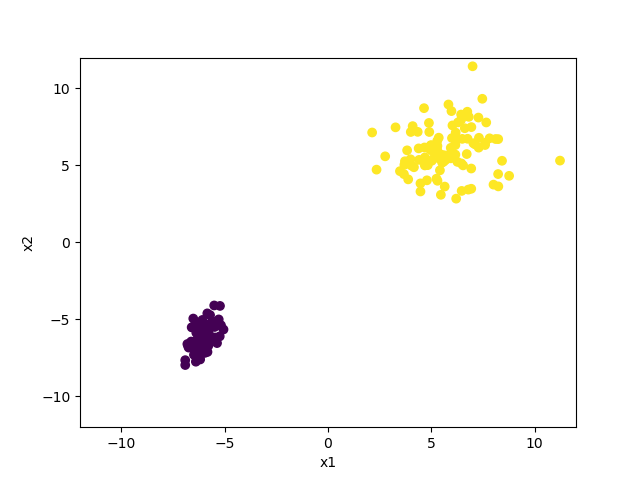
    

W naszym przypadku wzór perceptronu dla dwóch cech wygląda następująco: 

$$h_w(x) = f(w_0x_0 + w_1x_1 + w_2x_2)$$

Spójrzmy jeszcze jak wygląda wykres naszej funkcji aktywacji Heaviside’a, która decyduje o odpowiedzi perceptronu.

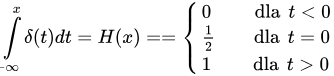

Analizując wykres, można zauważyć, że odpowiedź $0$ będzie w sytuacji, gdy wartość wchodząca do funkcji aktywacji będzie ujemna, a gdy będzie dodatnia, to odpowiedź będzie równa $1$. Dobrze, czyli wiemy, że żeby perceptron dał predykcję $1$, to ważona suma wejść musi być większa od zera, w przeciwnym przypadku da odpowiedź $0$. Zapiszmy to.

$h_w(x) = 1$ jeśli

$$w_0x_0 + w_1x_1 + w_2x_2 > 0$$ 

$h_w(x) = 0$ jeśli 

$$w_0x_0 + w_1x_1 + w_2x_2 < 0$$ 

Czyli wynika z tego, że zmiana decyzji predykcji jest wtedy, gdy ważona suma będzie równa $0$. Wykres funkcji aktywacji to potwierdza.

$$w_0x_0 + w_1x_1 + w_2x_2 = 0$$


Załóżmy, że za pomocą algorytmu perceptronu znaleźliśmy następujące wartości wag: $[-5, 1, 1]$. Podstawmy te wartości do równania.

$$-5 + 1x_1 + 1x_2 = 0$$ 

Pamiętamy, że $x_0$ ma zawsze wartość $1$, więc pomijamy je w równaniu. Teraz przekształćmy równanie tak, aby po lewej stronie były niewiadome.

$$x_1 + x_2 = 5$$ 
$$x_2 = -x_1 + 5$$

To co otrzymaliśmy, to równanie prostej o współczynniku kierunkowym $-1$. Prosta ta przetnie oś $x_2$ w punkcie $(0,5)$, a oś $x_1$ w punkcie $(5,0)$. Nanieśmy prostą na nasz wykres z zestawem danych.

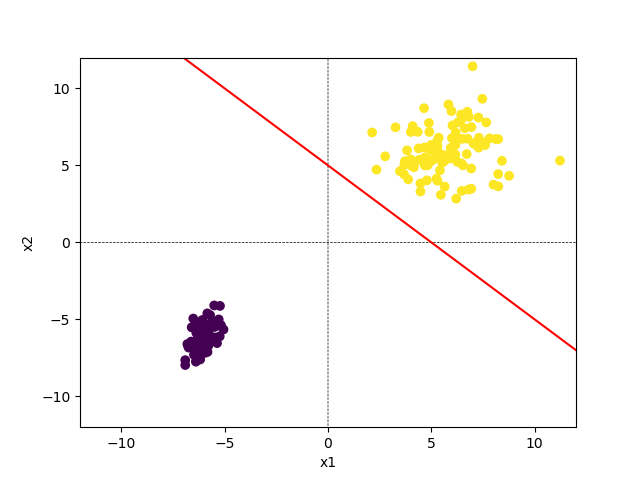

Prosta, którą nanieśliśmy na wykres, to **granica decyzyjna** (ang. decision boundary). Jest to miejsce miejsce, w którym następuje zmiana predykcji. Wszystkie próbki, które znajdą się poniżej prostej będą zaklasyfikowane jako klasa $0$, a te powyżej, jako klasa $1$.


### Jak narysować granicę decyzyjną

Równanie ogólne prostej ma postać $Ax + By + C = 0$

W naszym przypadku: 

$w_{1}x_{1} + w_{2}x_{2} + w_{0}x_{0} = 0$, gdzie $x_{0} = 1$

Dlaczego = $0$? Ponieważ w tym miejscu następuje zmiana decyzji klasyfikacji - zgodnie z wykresem funkcji skokowej Heaviside'a.

Teraz chcemy przekształcić równanie w taki sposób, żeby tylko $x_{2}$ było po lewej stronie stronie równania, czyli chcemy przejść z równania ogólnego prostej na równanie kierunkowe. Dokładnie tak jak się to robiło w szkole średniej np. [przykład](https://zadaniacke.pl/teoria/rownanie-kierunkowe-i-ogolne-prostej/)

$w_{1}x_{1} + w_{2}x_{2} + w_{0}x_{0} = 0$ <- równanie OGÓLNE prostej

$w_{2}x_{2} = -(w_{1}x_{1} + w_{0})$


$x_{2} = \frac{-(w_{1}x_{1} + w_{0})}{w_{2}}$ <- równanie KIERUNKOWE prostej

Mając równanie kierunkowe prostej w łatwy sposób możemy stworzyć rysunek granicy decyzyjnej.

Przykładowy kod tworzący granicę decyzyjną w zadanym przedziale wartości:

```python
import matplotlib.pyplot as plt
import numpy as np

# ustalamy wagi
w = [2, 3, 1.5]

# tworzymy punkty na osi x1
x1 = np.linspace(-5, 5, 100)

# obliczamy x2 (y) dla wszystkich punktów x1 na podstawie wybranych wag
x2 = -(w[1]*x1 + w[0])/w[2]

# podpisujemy osie
plt.xlabel("x1")
plt.ylabel("x2")

# dodajemy dodatkowo osie x i y, żeby wiedzieć gdzie jest punkt 0,0
zeros = np.zeros(100)
plt.plot(x1, zeros, c="black", linewidth=0.5, linestyle='--')
plt.plot(zeros, x1, c="black", linewidth=0.5, linestyle='--')

# ograniczamy widoczność wykresu do zakresu -5, 5 dla obu osi
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.plot(x1, x2)
plt.show()
```

### Zadanie 1

W pliku o nazwie Ankieta.csv zajdują się dane z omawianej wcześniej ankiety. Każdy rekord zawiera informacje o wzroście oraz wadze, a ostatnią kolumną jest płeć. 

* Zaimplementuj algorym perceptronu, który będzie skutecznie klasyfikował próbki znajdujące się w zestawie danych. Sugerowane jest stworzenie ogólnej implementacji perceptronu, który będzie w stanie rozwiązać problem dla dowolnej ilości cech w zestawie danych.
* Porównaj czasy działania algorytmu dla oryginalnego i znormalizowanego zestawu danych. Jak normalizacja danych wpływa na algorytm perceptronu?

_Uwaga: w zbiorze danych Ankieta.csv kolumna "Plec" ma wartości tekstowe. Przed implementacją konieczne jest przemapowanie ich do postaci liczbowej. Np. Kobieta - 1, Mezczyzna - 0._

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import time
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D

from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv("Ankieta.csv")
df.head()

,waga,wzrost,plec
0,55,160,Kobieta
1,78,180,Mezczyzna
2,55,150,Kobieta
3,99,196,Mezczyzna
4,90,180,Mezczyzna


<Axes: xlabel='waga', ylabel='wzrost'>

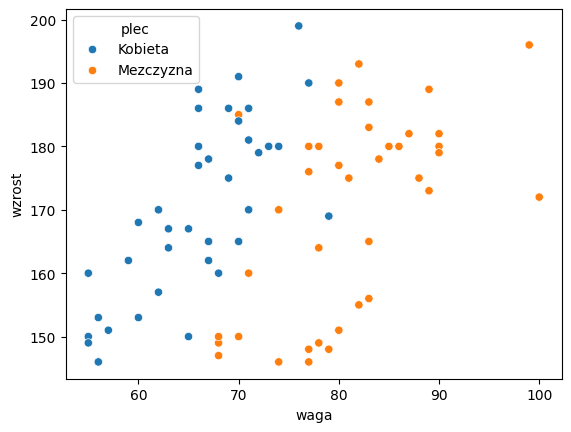

In [3]:
sns.scatterplot(data=df, x='waga', y='wzrost', hue='plec')

In [4]:
df['plec'].unique()

array(['Kobieta', 'Mezczyzna'], dtype=object)

In [5]:
df['plec'] = df['plec'].map({'Kobieta': 1, 'Mezczyzna' : 0})
df.head()

,waga,wzrost,plec
0,55,160,1
1,78,180,0
2,55,150,1
3,99,196,0
4,90,180,0


In [6]:
X = df.drop(columns=['plec']).values
y = df['plec'].values

In [7]:
def perceptron_train(X, y, alpha=0.01, epochs=100):
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    b = 0
    #w = np.random.uniform(-0.01, 0.01, size=n_features)
    #b = np.random.uniform(-0.01, 0.01)

    epoch_history = []

    for epoch in range(epochs):
        errors = 0
        
        for i in range(n_samples):
            linear_output = np.dot(X[i], w) + b
            if linear_output >= 0:
                y_pred = 1
            else:
                y_pred = 0
                
            error = y[i] - y_pred
            if error != 0:
                errors += 1
                
            w += alpha * error * X[i]
            b += alpha * error
        epoch_history.append((w.copy(), b))

        if errors == 0:
            print(f"Uczenie zakończone po {epoch+1} epokach")
            break

    return w, b, epoch_history

##### Test predykcji na danych nieznormalizowanych

In [8]:
start = time.time()
w, b, history = perceptron_train(X, y, alpha=0.00001, epochs=500)
end = time.time()

print('Czas uczenia:', end - start)

Czas uczenia: 0.6885931491851807


##### Test predykcji na danych znormalizowanych

In [9]:
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

start = time.time()
w_n, b_n, history_n = perceptron_train(X_norm, y, alpha=0.00001, epochs=500)
end = time.time()

print('Dane znormalizowane:')
print('Czas uczenia:', end - start)

Dane znormalizowane:
Czas uczenia: 0.6680638790130615


Czas obliczeń algorytmu dla danych znormalizowanych zmniejszył się względem czasu dla danych oryginalnych.

### Zadanie 2

Stwórz wykres przedstawiający dane z pliku Ankieta.csv w dwuwymiarowej przestrzeni wraz z granicą decyzyjną obliczoną w poprzednim zadaniu. Dodatkowo, 3 wykresy na których pokażesz jak zmieniała się granica decyzyjna na przestrzeni epok.

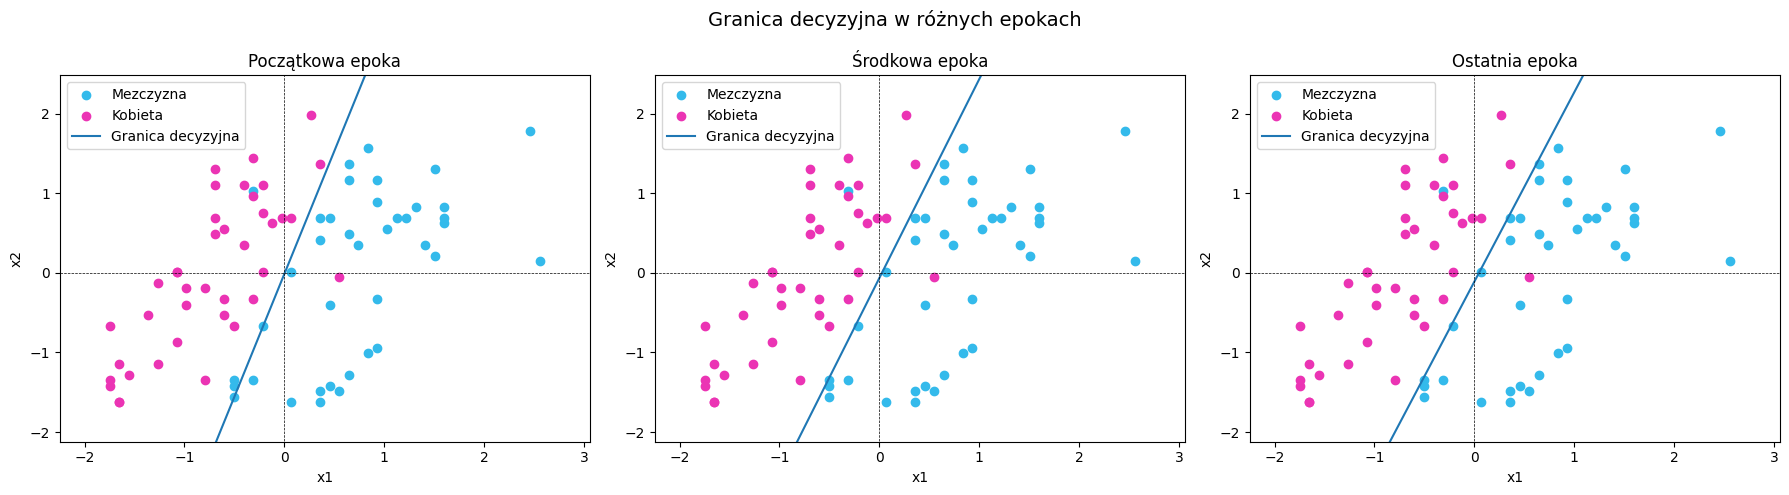

In [10]:
epochs_to_plot = [0, len(history)//2, -1]
titles = ['Początkowa epoka', 'Środkowa epoka', 'Ostatnia epoka']

color_men = '#34baeb'
color_women = '#eb34b4'

fig, axes = plt.subplots(1, 3, figsize=(18, 5))


for ax, idx, title in zip(axes, epochs_to_plot, titles):
    w, b = history[idx]
    x1_min, x1_max = X_norm[:, 0].min() - 0.5, X_norm[:, 0].max() + 0.5
    x2_min, x2_max = X_norm[:, 1].min() - 0.5, X_norm[:, 1].max() + 0.5
    x1 = np.linspace(x1_min, x1_max, 100)
    x2 = -(w[0] * x1 + b) / w[1]
    zeros = np.zeros_like(x1)
    
    ax.scatter(X_norm[y == 0][:, 0], X_norm[y == 0][:, 1], label='Mezczyzna', color=color_men)
    ax.scatter(X_norm[y == 1][:, 0], X_norm[y == 1][:, 1], label='Kobieta', color=color_women)
    # granica decyzyjna
    ax.plot(x1, x2, label='Granica decyzyjna')
    # osie pomocnicze
    ax.plot(x1, zeros, c='black', linewidth=0.5, linestyle='--')
    ax.plot(zeros, x1, c='black', linewidth=0.5, linestyle='--')
    
    
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_xlim(x1_min, x1_max)
    ax.set_ylim(x2_min, x2_max)
    ax.set_title(title)
    ax.legend()


fig.suptitle('Granica decyzyjna w różnych epokach', fontsize=14)
plt.tight_layout()
plt.show()

### Zadanie 3

Stwórz wykresy dla różnych współczynników uczenia alpha. Jakie widzisz zależności?

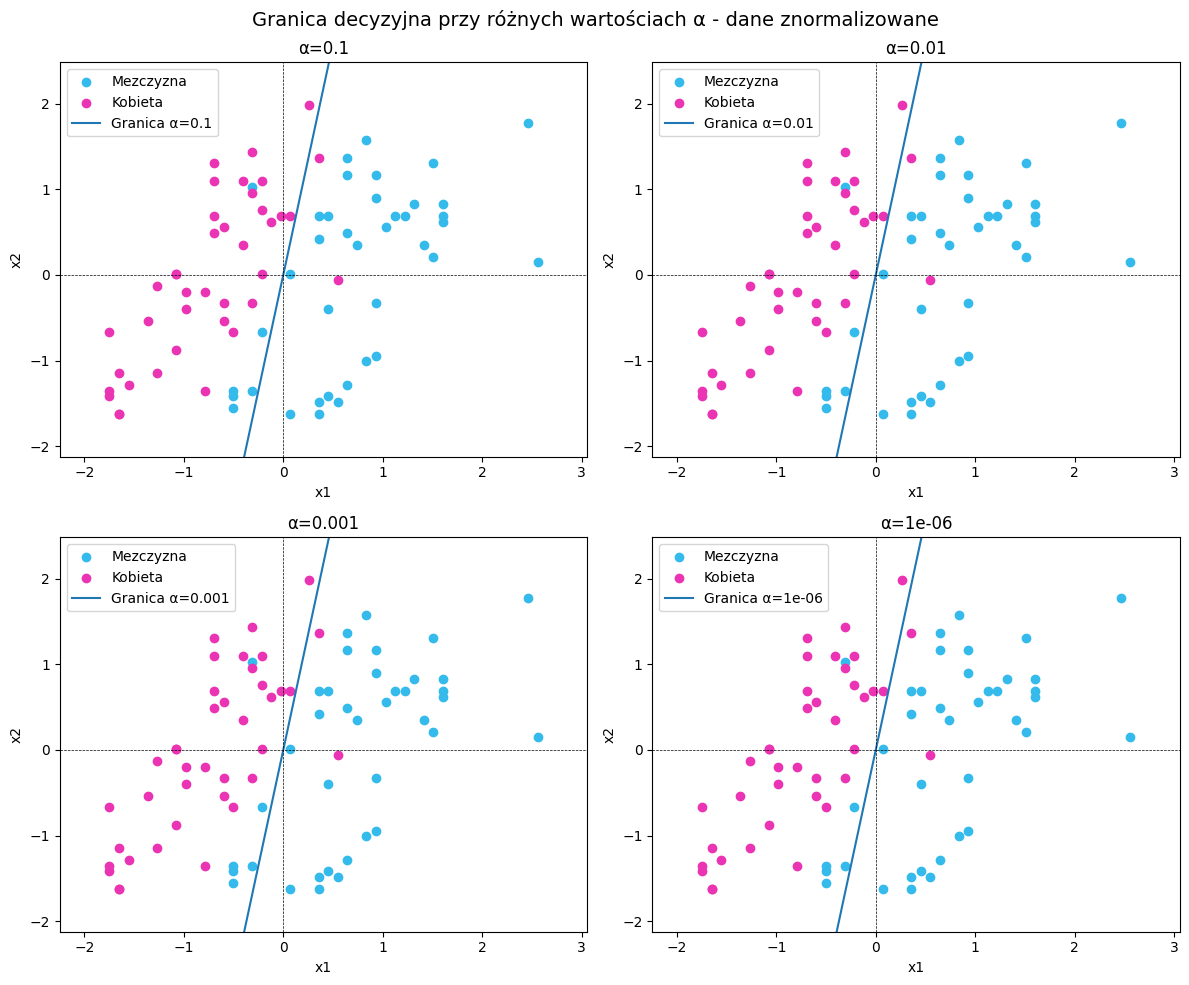

In [11]:
alphas = [0.1, 0.01, 0.001, 0.000001]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()


for ax, alpha in zip(axes, alphas):
    w_a, b_a, history_a = perceptron_train(X_norm, y, alpha=alpha, epochs=500)
    x1_min, x1_max = X_norm[:, 0].min() - 0.5, X_norm[:, 0].max() + 0.5
    x2_min, x2_max = X_norm[:, 1].min() - 0.5, X_norm[:, 1].max() + 0.5
    x1 = np.linspace(x1_min, x1_max, 100)
    x2 = -(w_a[0] * x1 + b_a) / w_a[1]
    zeros = np.zeros_like(x1)
    
    ax.scatter(X_norm[y == 0][:, 0], X_norm[y == 0][:, 1], label='Mezczyzna', color=color_men)
    ax.scatter(X_norm[y == 1][:, 0], X_norm[y == 1][:, 1], label='Kobieta', color=color_women)
    ax.plot(x1, x2, label=f'Granica α={alpha}')
    ax.plot(x1, zeros, c='black', linewidth=0.5, linestyle='--')
    ax.plot(zeros, x1, c='black', linewidth=0.5, linestyle='--')
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_xlim(x1_min, x1_max)
    ax.set_ylim(x2_min, x2_max)
    ax.set_title(f'α={alpha}')
    ax.legend()

fig.suptitle('Granica decyzyjna przy różnych wartościach α - dane znormalizowane', fontsize=14)
plt.tight_layout()
plt.show()

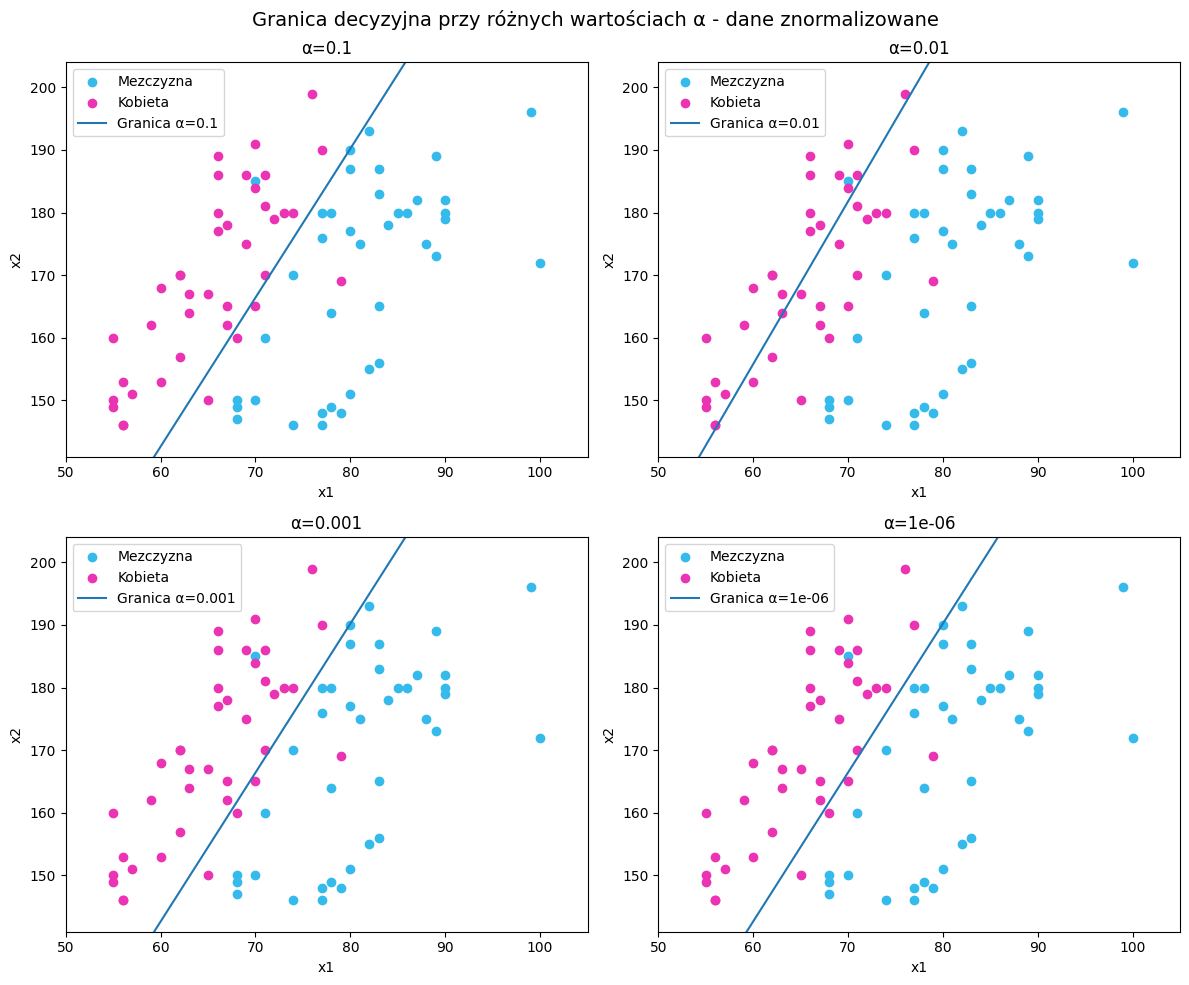

In [12]:
alphas = [0.1, 0.01, 0.001, 0.000001]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()


for ax, alpha in zip(axes, alphas):
    w_a, b_a, history_a = perceptron_train(X, y, alpha=alpha, epochs=500)
    x1_min, x1_max = X[:, 0].min() - 5, X[:, 0].max() + 5
    x2_min, x2_max = X[:, 1].min() - 5, X[:, 1].max() + 5
    x1 = np.linspace(x1_min, x1_max, 100)
    x2 = -(w_a[0] * x1 + b_a) / w_a[1]
    zeros = np.zeros_like(x1)
    
    ax.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label='Mezczyzna', color=color_men)
    ax.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label='Kobieta', color=color_women)
    ax.plot(x1, x2, label=f'Granica α={alpha}')
    ax.plot(x1, zeros, c='black', linewidth=0.5, linestyle='--')
    ax.plot(zeros, x1, c='black', linewidth=0.5, linestyle='--')
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_xlim(x1_min, x1_max)
    ax.set_ylim(x2_min, x2_max)
    ax.set_title(f'α={alpha}')
    ax.legend()

fig.suptitle('Granica decyzyjna przy różnych wartościach α - dane znormalizowane', fontsize=14)
plt.tight_layout()
plt.show()

W przypadku danych znormalizowanych, zmiana parametru alpha nie przynosi większych skutków - uczenie jest stabilne, dodatkowo dla większych wartośći uzyskujemy dobre wyniki.
Dla danych znormalizowanych zauważalne są większe różnice przy wyborze parametru. Alphy muszą być zdecydowanie mniejsze aby uzyskać racjonalną granicę.

### Zadanie 4

Oblicz skuteczność predykcji perceptronu

In [13]:
def perceptron_predict(X, w, b):
    linear_output = np.dot(X, w) + b
    return np.where(linear_output >= 0, 1, 0)

In [14]:
def perceptron_accuracy(X, y, w, b):
    y_pred = perceptron_predict(X, w, b)
    correct = sum(1 for i in range(len(y)) if y_pred[i] == y[i])

    accuracy = correct / len(y)
    
    return accuracy

In [15]:
start = time.time()
w, b, history = perceptron_train(X, y, alpha=0.00001, epochs=500)
end = time.time()

print('Czas uczenia:', end - start)
print('Dokładność:', perceptron_accuracy(X, y, w, b))

Czas uczenia: 1.007328987121582
Dokładność: 0.9358974358974359


In [16]:
w, b, history = perceptron_train(X, y, alpha=0.0001, epochs=100)
acc = perceptron_accuracy(X, y, w, b)
print(f"Accuracy, alpha=0.0001, epochs=100: {acc:.3f}")

Accuracy, alpha=0.0001, epochs=100: 0.551


In [17]:
w, b, history = perceptron_train(X, y, alpha=0.0001, epochs=1000)
acc = perceptron_accuracy(X, y, w, b)
print(f"Accuracy, alpha=0.0001, epochs=1000: {acc:.3f}")

Accuracy, alpha=0.0001, epochs=1000: 0.846


### Zadanie 5

Spróbuj zaimplementować inne warunek wykonania pętli uczącej. Który znajduje rozwiązanie najszybciej?

In [18]:
# pozwalamy na ustaloną liczbę źle zaklasyfikowanych próbek - w tym przypadku 5
def perceptron_train_tolerance(X, y, alpha=0.01, epochs=100, tolerance=5):
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    b = 0

    epoch_history = []

    for epoch in range(epochs):
        errors = 0

        for i in range(n_samples):
            linear_output = np.dot(X[i], w) + b
            y_pred = 1 if linear_output >= 0 else 0

            error = y[i] - y_pred
            if error != 0:
                errors += 1

            w += alpha * error * X[i]
            b += alpha * error

        epoch_history.append((w.copy(), b))


        if errors <= tolerance:
            print(
                f"Uczenie zakończone po {epoch+1} epokach "
                f"(błędy w epoce: {errors})"
            )
            break

    return w, b, epoch_history

In [19]:
w1, b1, hist1 = perceptron_train(X, y, alpha=0.00001, epochs=5000)

w2, b2, hist2 = perceptron_train_tolerance(X, y, alpha=0.00001, epochs=5000, tolerance=5)

print("Epoki (zero błędów):", len(hist1))
print("Epoki (tolerancja):", len(hist2))

Epoki (zero błędów): 5000
Epoki (tolerancja): 5000


In [20]:
#Dane znormalizowane
w1, b1, hist1 = perceptron_train(X_norm, y, alpha=0.01, epochs=5000)

w2, b2, hist2 = perceptron_train_tolerance(X_norm, y, alpha=0.01, epochs=5000, tolerance=10)

print("Epoki (zero błędów):", len(hist1))
print("Epoki (tolerancja):", len(hist2))

Uczenie zakończone po 1 epokach (błędy w epoce: 6)
Epoki (zero błędów): 5000
Epoki (tolerancja): 1


##### Przy tak dobranych rozwiązaniach zawsze to z ustalonym poziomem tolerancji będzie kończyło algorytm szybciej niż z całkowitym dopasowaniem - można natomiast wtedy zobaczyć, jak niewiele błędów i jak szybko nasz algorytm zdołał uzyskać. Ustalenie odpowiedniego progu może być mocno eksperymentalne, więc zdecydowano się na zaimplementowanie dodatkowo wersji z procentową tolerancją.

In [21]:
def perceptron_train_tolerance_percent(X, y, alpha=0.01, epochs=100, tolerance_percent=0.05):
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    b = 0

    epoch_history = []

    for epoch in range(epochs):
        errors = 0

        for i in range(n_samples):
            linear_output = np.dot(X[i], w) + b
            y_pred = 1 if linear_output >= 0 else 0

            error = y[i] - y_pred
            if error != 0:
                errors += 1

            w += alpha * error * X[i]
            b += alpha * error

        epoch_history.append((w.copy(), b))

        error_rate = errors / n_samples

        if error_rate <= tolerance_percent:
            print(
                f"Uczenie zakończone po {epoch+1} epokach "
                f"(błędy: {errors}, {error_rate:.2%})"
            )
            break

    return w, b, epoch_history

In [22]:
#Dane przed normalizacją
w1, b1, hist1 = perceptron_train_tolerance(X, y, alpha=0.01, epochs=500, tolerance=2)

w2, b2, hist2 = perceptron_train_tolerance_percent(X, y, alpha=0.01, epochs=500, tolerance_percent=0.05)

print("Epoki – tolerancja liczby błędów:", len(hist1))
print("Epoki – tolerancja procentowa:", len(hist2))

Epoki – tolerancja liczby błędów: 500
Epoki – tolerancja procentowa: 500


In [23]:
# Dane znormalizowane
w1, b1, hist1 = perceptron_train_tolerance(X_norm, y, alpha=0.01, epochs=500, tolerance=5)

w2, b2, hist2 = perceptron_train_tolerance_percent(X_norm, y, alpha=0.01, epochs=500, tolerance_percent=0.05)

print("Epoki – tolerancja liczby błędów:", len(hist1))
print("Epoki – tolerancja procentowa:", len(hist2))

Uczenie zakończone po 2 epokach (błędy w epoce: 5)
Epoki – tolerancja liczby błędów: 2
Epoki – tolerancja procentowa: 500


### Zadanie 6

Wykorzystaj stworzony algorym w celu znalezienia granicy decyzyjnej będącej płaszczyzną w trójwymiarowej przestrzeni. Zbiór danych znajduje się w pliku o nazwie 3D_perceptron.csv. Stwórz wykres analogicznie jak w zadaniu 2.

In [24]:
df_3d = pd.read_csv("3D_perceptron.csv")

df_3d.head()

,x1,x2,x3,y
0,2.725907,10.023840,11.224807,1
1,0.680593,15.299426,14.318900,1
2,0.215521,12.710218,11.106429,1
3,-1.739506,-15.825530,-17.599468,0
4,-2.219526,9.772773,10.841995,1


In [25]:
X = df_3d.iloc[:, :-1].values
y = df_3d.iloc[:, -1].values

scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

In [26]:
w, b, history = perceptron_train(X, y, alpha=0.01, epochs=500)

Uczenie zakończone po 2 epokach


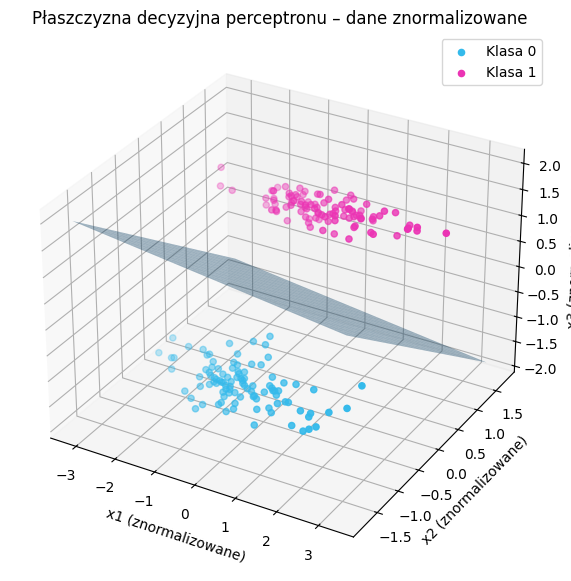

In [27]:
x1_min, x1_max = X_norm[:, 0].min() - 0.5, X_norm[:, 0].max() + 0.5
x2_min, x2_max = X_norm[:, 1].min() - 0.5, X_norm[:, 1].max() + 0.5

x1 = np.linspace(x1_min, x1_max, 20)
x2 = np.linspace(x2_min, x2_max, 20)

X1, X2 = np.meshgrid(x1, x2)
X3 = -(w[0] * X1 + w[1] * X2 + b) / w[2]

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_norm[y == 0][:, 0],
    X_norm[y == 0][:, 1],
    X_norm[y == 0][:, 2],
    label='Klasa 0',
    color='#34baeb'
)

ax.scatter(
    X_norm[y == 1][:, 0],
    X_norm[y == 1][:, 1],
    X_norm[y == 1][:, 2],
    label='Klasa 1',
    color='#eb34b4'
)

ax.plot_surface(X1, X2, X3, alpha=0.4)
ax.set_xlabel('x1 (znormalizowane)')
ax.set_ylabel('x2 (znormalizowane)')
ax.set_zlabel('x3 (znormalizowane)')
ax.set_title('Płaszczyzna decyzyjna perceptronu – dane znormalizowane')
ax.legend()
plt.show()

##### Grupy były dosyć dobrze odseparowane, natomiast algorytm odpowiednio sobie z nimi poradził.

### Zadanie 6

Znajdź dowolny zbiór danych, który może zostac zastosowany w problemie klasyfikacji (np. tutaj: https://archive.ics.uci.edu/). Spróbuj zastosować zaimplementowany algorytm na nowym zbiorze danych.

#### Wybrano dataset z ogólnodostępnej platformy Kaggle. Dane dotyczą zatwierdzania pożyczek na podstawie informacji takich jak zarobki.  
[Loan Approval Prediction Dataset na Kaggle](https://www.kaggle.com/datasets/architsharma01/loan-approval-prediction-dataset?resource=download)

Jako target wybrano kolumnę **loan_status** mówiąca czy decyzja jest pozytywna czy negatywana. Jako zmienne objaśniające wybrano 3 kolumny:
* income_annum – roczny dochód wnioskodawcy
* loan_amount – kwota kredytu
* cibil_score – ocena historii kredytowej wnioskodawcy

### Data Preproccesing

In [28]:
df = pd.read_csv("loan_approval_dataset.csv")
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [29]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [30]:
print(df.columns.tolist())

['loan_id', ' no_of_dependents', ' education', ' self_employed', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score', ' residential_assets_value', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value', ' loan_status']


In [31]:
df.columns = df.columns.str.strip()

In [32]:
df.loan_status.unique()

array([' Approved', ' Rejected'], dtype=object)

In [33]:
df['loan_status'] = df['loan_status'].str.strip()

<Axes: xlabel='income_annum', ylabel='loan_amount'>

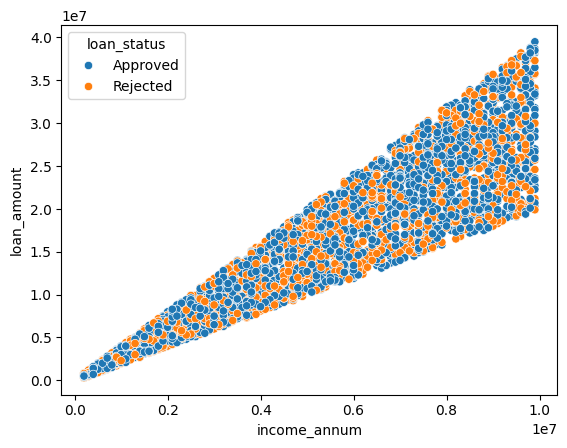

In [34]:
sns.scatterplot(data=df, x='income_annum', y='loan_amount', hue='loan_status')

<Axes: xlabel='income_annum', ylabel='cibil_score'>

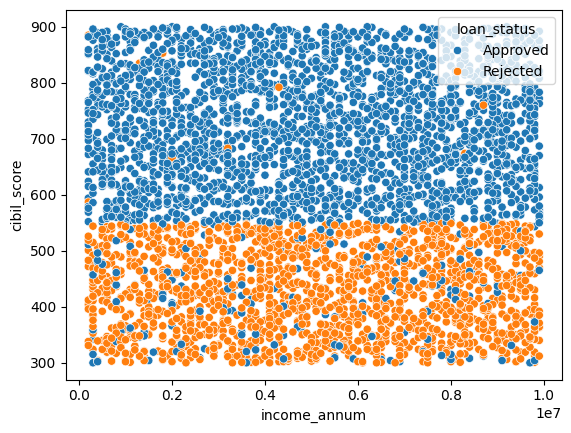

In [35]:
sns.scatterplot(data=df, x='income_annum', y='cibil_score', hue='loan_status')

In [36]:
features = [
    "income_annum", 
    "loan_amount", 
    "cibil_score"
]
target = "loan_status"

df = df.dropna(subset=features + [target])
df[target] = df[target].map({"Approved": 1, "Rejected": 0})


X = df[features].values
y = df[target].values


# normalizacja
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

In [37]:
w, b, history = perceptron_train(X_norm, y, alpha=0.001, epochs=1000)

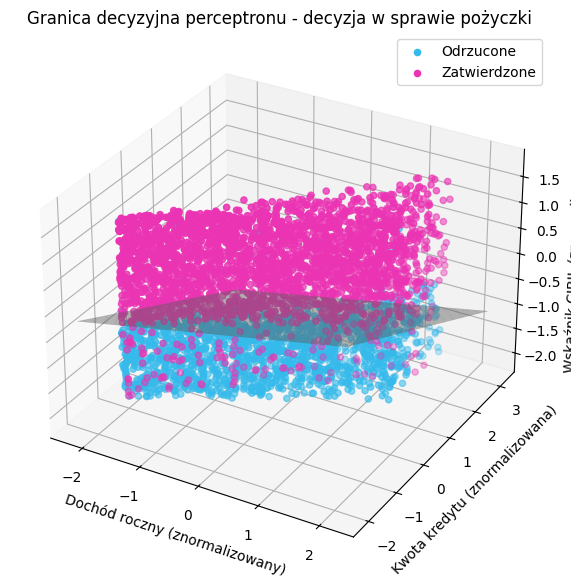

In [38]:
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_norm[y==0][:,0], X_norm[y==0][:,1], X_norm[y==0][:,2], color='#34baeb', label='Odrzucone')
ax.scatter(X_norm[y==1][:,0], X_norm[y==1][:,1], X_norm[y==1][:,2], color='#eb34b4', label='Zatwierdzone')


xx, yy = np.meshgrid(
    np.linspace(X_norm[:,0].min()-0.5, X_norm[:,0].max()+0.5, 50),
    np.linspace(X_norm[:,1].min()-0.5, X_norm[:,1].max()+0.5, 50)
)

zz = -(w[0]*xx + w[1]*yy + b)/w[2]


ax.plot_surface(xx, yy, zz, alpha=0.5, color='gray')
ax.set_xlabel('Dochód roczny (znormalizowany)')
ax.set_ylabel('Kwota kredytu (znormalizowana)')
ax.set_zlabel('Wskaźnik CIBIL (znormalizowany)')
ax.set_title('Granica decyzyjna perceptronu - decyzja w sprawie pożyczki')
ax.legend()

plt.show()

In [39]:
acc = perceptron_accuracy(X_norm, y, w, b)
print(f"Accuracy: {acc:.3f}")

Accuracy: 0.920


##### Perceptron wydzielił klasy w sposób dobry - dnae nie są łatwym przykładem, być może inne zmienne w danych bardziej nadawały się do przeprowadzenia klasyfikacji, w celu uproszczenia zadania nie sprawdzono tego. Na tak gęste dane cięzko zauważyć jak dobra jest granica, ale dokładność wynosząca 92% jest w pełni satysfakcjonująca.

### Zadanie 7

Porównaj działanie swojego algorytmu z algorytmem perceptronu dostępnym w Scikit-learn

In [40]:
clf = Perceptron(alpha=0.0, max_iter=100, eta0=0.01, random_state=42, tol=1e-3)

start_time = time.time()  # start pomiaru czasu
clf.fit(X_norm, y)
end_time = time.time()    # koniec pomiaru czasu

y_pred_skl = clf.predict(X_norm)
acc_skl = accuracy_score(y, y_pred_skl)

print(f"Scikit-learn Perceptron - Accuracy: {acc_skl:.4f}, Czas uczenia: {end_time - start_time:.4f} s")

Scikit-learn Perceptron - Accuracy: 0.8730, Czas uczenia: 0.0090 s


In [41]:
start_time = time.time()  # start pomiaru czasu
w, b, epoch_history = perceptron_train(X_norm, y, alpha=0.01, epochs=100)
end_time = time.time()    # koniec pomiaru czasu

y_pred_custom = np.where(np.dot(X_norm, w) + b >= 0, 1, 0)
acc_custom = accuracy_score(y, y_pred_custom)

print(f"Własny perceptron - Accuracy: {acc_custom:.4f}, Czas uczenia: {end_time - start_time:.4f} s")

Własny perceptron - Accuracy: 0.8955, Czas uczenia: 7.1474 s


##### WNIOSKI - porównanie implementacji własnej oraz Scikit Learn:
Dokładność modelu jest zbliżona dla obu rozwiązań, przy czym własna implementacja w tym konkretnym przypadku osiągnęła nieco wyższe wyniki na zbiorze treningowym. Z dostępnych źródeł i informacji wynika, że moze być to spowodowane lepszą generalizacją modeli w przypadku algorytmu z biblioteki. Perceptron z biblioteki Scikit-learn wykazał natomiast ogromną przewagę pod kątem czasów uczenia